# Smoking & Drinking — YOLOv8 Detection Data Preparation  *(class-balanced)*

**Scope :** build a clean, training-ready object-detection dataset for the **smoking** and
**drinking** classes. This notebook does *only* the data side —
**download (Roboflow) → merge → validate → EDA → balance → dedup → split → augment → export** — and hands off
a ready-to-train Ultralytics YOLOv8 dataset (`data.yaml` + `images/` + `labels/`). Model training
happens in a separate notebook.

> **What changed in this version (reviewer fix).** The previous notebook corrected class
> imbalance by augmenting the minority class up to **~17×**, which overfits and generalizes
> poorly. This version fixes imbalance at the **source and sampling** level instead:
>
> 1. **A ready-made balanced dataset** is pulled from Roboflow
>    (`yolo-dataset-rtznj/smoking-and-drinking-detection`) that already contains *both* smoking
>    and drinking, so the classes start out close in size.
> 2. **Real-image balancing (Section 8.5):** after cleaning + dedup, the majority class is
>    **capped down** to at most `MAX_IMBALANCE_RATIO` × the minority class using real images —
>    no synthetic duplication.
> 3. **Augmentation is light and clamped:** a uniform `AUG_PER_IMAGE` (default 2), and any
>    residual minority top-up is **hard-capped** by `MAX_MINORITY_EXTRA` (default 2). The old
>    unbounded `round(max/min)-1` multiplier that produced ~17× is gone.
>
> Everything else — name-based harmonization, integrity quarantine, the full EDA suite, perceptual
> dedup, stratified split, bbox-aware augmentation, parallel export — is preserved.

### Design principles
1. **Datasets are harmonized by class *name*, not index.** Each source's `data.yaml` `names:` is
   read and remapped into one unified schema, so mismatched index orders can't corrupt labels.
2. **Non-target classes are dropped, not remapped.** Anything that isn't smoking/drinking
   (person, hands-on-wheel, sleeping, phone, …) is discarded so it can't masquerade as a target.
3. **Validation before analysis.** Corrupt images, missing/malformed labels, out-of-range
   coordinates and unmapped classes are quarantined first.
4. **Balance with real data, then split, then augment train only.**
5. **Bounding-box-aware augmentation** via Albumentations (boxes transform with the pixels).
6. **Reproducible** — single global seed, deterministic split/balance, one config cell.

### Pipeline
```
Roboflow (API) ──> load & index all sources ──> integrity validation
      ──> class harmonization (BY NAME) ──> drop non-target & empty images ──> EDA
      ──> dedup ──> BALANCE (cap majority to real minority) ──> stratified split
      ──> augment TRAIN only (light, clamped) ──> export YOLOv8
```

> Run top-to-bottom in Google Colab (GPU not required for prep). The only cell you *must* edit is
> the **Config** cell — set your Roboflow API key there (no Google Drive needed). Outputs below are cleared; they
> regenerate when you run the notebook.


## 1 · Environment setup

Albumentations handles bbox-aware augmentation; PyYAML reads each source's `data.yaml`; the
`roboflow` package downloads the balanced dataset; `imagehash` powers dedup. The first line
installs anything missing (safe to re-run).


In [ ]:
# Install anything missing (quiet). Safe to re-run; skip if already present.
!pip -q install roboflow imagehash albumentations >/dev/null 2>&1

import os, sys, glob, shutil, random, hashlib, json, re, warnings
from pathlib import Path
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image, ImageFile
import cv2
import yaml
import albumentations as A
from tqdm.notebook import tqdm
from roboflow import Roboflow

warnings.filterwarnings("ignore")
ImageFile.LOAD_TRUNCATED_IMAGES = False   # we WANT truncated files to raise, so we can quarantine them
pd.set_option("display.max_columns", 60)

SEED = 42
random.seed(SEED); np.random.seed(SEED)

print("albumentations", A.__version__, "| opencv", cv2.__version__)


albumentations 2.0.8 | opencv 4.10.0


## 2 · Data source (Roboflow API)

The dataset is downloaded directly from **Roboflow** in YOLOv8 format (YOLO `.txt` labels) using
your API key — no Google Drive, no manual uploads. The default project
(`yolo-dataset-rtznj/smoking-and-drinking-detection`) already contains **both** smoking and
drinking, so the two classes start out balanced. You can add more Roboflow projects in the Config
cell; the pipeline merges them by class name and re-balances automatically (Section 8.5).


## 3 · Configuration — **edit this cell only**

Set your **Roboflow API key** here, choose sources, and tune the split / balancing / augmentation.

**Harmonization is by class name, not index** — each source's `data.yaml` `names:` is mapped onto
the unified schema via `CLASS_SYNONYMS`; anything not a smoking/drinking synonym is dropped.

**The imbalance fix lives here too:** `MAX_IMBALANCE_RATIO` caps the majority class with real
images (Section 8.5), and `MAX_MINORITY_EXTRA` hard-caps minority augmentation so it can never
blow up to ~17× again.


In [ ]:
# ════════════════ EDIT BELOW ════════════════

# --- Roboflow API key -------------------------------------------------------
# Get a private key at https://app.roboflow.com/settings/api
# (or set an env var ROBOFLOW_API_KEY and leave this as-is).
RF_API_KEY = os.environ.get("ROBOFLOW_API_KEY", "MLhcVMC2hMublLYC9yQM")

# --- Roboflow sources: (workspace, project, version_or_None, tag) -----------
# version=None -> use the LATEST version automatically.
# The first entry is a ready-made BALANCED smoking+drinking set (both classes),
# which is what removes the imbalance at the SOURCE instead of via ~17x augmentation.
ROBOFLOW_SOURCES = [
    # PRIMARY (large, ~8.3k imgs, both classes as actions: smoking/cigarette + drinking).
    # eating & mobile classes are auto-dropped by the name-based harmonizer.
    ("case1-dmyty", "eating-drinking-mobile-smoking", 1, "rf_edms"),
    # optional supplement (the small ~1k balanced set from before):
    # ("yolo-dataset-rtznj", "smoking-and-drinking-detection", None, "rf_balanced"),
]


# --- Final unified label schema (index = position in this list) -------------
UNIFIED_CLASSES = ["smoking", "drinking"]          # -> smoking=0, drinking=1

# --- Name-based harmonization -----------------------------------------------
# Source class names are normalized (lowercased, non-alphanumerics -> "_") and matched
# against these synonym sets. Anything matching nothing is DROPPED.
CLASS_SYNONYMS = {
    "smoking":  {"smoking", "smoke", "cigarette", "cig", "smoker"},
    "drinking": {"drinking", "drink", "drinks", "beverage", "bottle",
                 "drinking_water", "has_bottle"},
}

# Optional manual override for odd names: {tag: {raw_name: unified_or_None}}.
MANUAL_NAME_OVERRIDES = {}

# Keep only images with >=1 smoking/drinking box (False = drop pure-background images).
KEEP_NEGATIVES = False

# --- Output / scratch -------------------------------------------------------
OUTPUT_ROOT = "smoking_drinking_yolo_balanced"   # final dataset folder / zip name
WORK_DIR    = "/content/work"                     # fast local scratch (Colab SSD)

# --- Split ratios (must sum to 1.0) -----------------------------------------
SPLIT = {"train": 0.80, "val": 0.10, "test": 0.10}

# --- Class balancing (THE REVIEWER FIX) -------------------------------------
# Instead of augmenting the minority class ~17x (overfits), balance with REAL images:
# after cleaning + dedup, cap the majority class down to at most MAX_IMBALANCE_RATIO x
# the minority. Augmentation is then light + uniform, with a hard-capped minority top-up.
MAX_IMBALANCE_RATIO = 1.25   # majority images kept <= 1.25x minority images (Section 8.5)
AUG_PER_IMAGE       = 2      # uniform augmented copies per TRAIN image
BALANCE_CLASSES     = True   # allow a small extra minority top-up (clamped below)
MAX_MINORITY_EXTRA  = 2      # HARD CAP on extra minority aug copies (old code was unbounded)
IMG_EXTS            = (".jpg", ".jpeg", ".png", ".bmp", ".webp")

# ════════════════ EDIT ABOVE ════════════════

CLASS_TO_ID = {c: i for i, c in enumerate(UNIFIED_CLASSES)}
ID_TO_CLASS = {i: c for c, i in CLASS_TO_ID.items()}
assert abs(sum(SPLIT.values()) - 1.0) < 1e-6, "SPLIT must sum to 1.0"
Path(WORK_DIR).mkdir(parents=True, exist_ok=True)
print("Unified classes:", CLASS_TO_ID)
print("Balancing: cap majority <= %.2fx minority | aug/image=%d | minority extra clamp=%d"
      % (MAX_IMBALANCE_RATIO, AUG_PER_IMAGE, MAX_MINORITY_EXTRA))


Unified classes: {'smoking': 0, 'drinking': 1}
Balancing: cap majority <= 1.25x minority | aug/image=2 | minority extra clamp=2


### 3.0 · Download sources & build the source list

Downloads each Roboflow project (YOLOv8 export) into `WORK_DIR/sources/<tag>/` and assembles
`SOURCES` — the list every later stage iterates over. Re-running skips anything already downloaded.


In [ ]:
# Download every Roboflow source (YOLOv8 = YOLO .txt labels) and build SOURCES.
DL_ROOT = Path(WORK_DIR) / "sources"
DL_ROOT.mkdir(parents=True, exist_ok=True)

if not RF_API_KEY or RF_API_KEY == "PASTE_YOUR_ROBOFLOW_KEY":
    raise ValueError("Set RF_API_KEY in the Config cell (or the ROBOFLOW_API_KEY env var).")

rf = Roboflow(api_key=RF_API_KEY)

SOURCES = []   # each: {"root": str, "tag": str}
for ws, proj_name, ver, tag in ROBOFLOW_SOURCES:
    dst = DL_ROOT / tag
    if dst.exists() and any(dst.rglob("data.yaml")):
        print(f"[{tag}] already present -> {dst}")
    else:
        project = rf.workspace(ws).project(proj_name)
        if ver is None:                          # auto-pick the latest version
            try:
                vers = project.versions()
                ver = vers[-1].version if vers else 1
            except Exception:
                ver = 1
        print(f"[{tag}] downloading {ws}/{proj_name} v{ver} ...")
        project.version(int(ver)).download("yolov8", location=str(dst))
    SOURCES.append({"root": str(dst), "tag": tag})

assert SOURCES, "No data sources configured — add at least one ROBOFLOW_SOURCES entry."
print("\nActive sources:")
for s in SOURCES:
    print(f"  {s['tag']:>12}  ->  {s['root']}")


loading Roboflow workspace...
loading Roboflow project...
[rf_edms] downloading case1-dmyty/eating-drinking-mobile-smoking v1 ...



Extracting Dataset Version Zip to /content/work/sources/rf_edms in yolov8:: 100%|██████████| 16678/16678 [00:03<00:00, 4894.83it/s]



Active sources:
       rf_edms  ->  /content/work/sources/rf_edms


### 3.1 Read each dataset's real class names and build a name-based map

This cell reads `data.yaml` (or `classes.txt`) from each dataset root, then prints the exact
source-id → unified-name mapping it will use. **Read this output** — it is the single most
important audit in the pipeline. Every dropped class is shown as `DROP`.

In [ ]:
def _norm(name: str) -> str:
    """lowercase, collapse non-alphanumerics to underscore."""
    return re.sub(r"[^a-z0-9]+", "_", str(name).strip().lower()).strip("_")

# invert synonyms -> unified (all normalized)
_SYN_TO_UNIFIED = {}
for _unified, _syns in CLASS_SYNONYMS.items():
    for _s in _syns:
        _SYN_TO_UNIFIED[_norm(_s)] = _unified


def read_class_names(root: str) -> dict:
    """Return {src_id: raw_name} from data.yaml (Ultralytics) or classes.txt."""
    root = Path(root)
    yamls = list(root.rglob("data.yaml")) + [y for y in root.rglob("*.yaml")
                                             if y.name != "data.yaml"]
    for yml in sorted(yamls):
        try:
            d = yaml.safe_load(yml.read_text())
        except Exception:
            continue
        names = d.get("names") if isinstance(d, dict) else None
        if isinstance(names, dict):                       # {0: 'smoking', ...}
            return {int(k): str(v) for k, v in names.items()}
        if isinstance(names, list):                       # ['smoking', ...]
            return {i: str(v) for i, v in enumerate(names)}
    for ct in sorted(root.rglob("classes.txt")):          # fallback
        lines = [l.strip() for l in ct.read_text().splitlines() if l.strip()]
        if lines:
            return {i: n for i, n in enumerate(lines)}
    raise FileNotFoundError(
        f"No data.yaml / classes.txt with class names found under {root}. "
        f"Add one, or fill MANUAL_NAME_OVERRIDES.")


def build_class_map(root: str, source_tag: str) -> dict:
    """src_id -> unified_name or None (None = drop this class)."""
    raw = read_class_names(root)
    overrides = {_norm(k): v for k, v in MANUAL_NAME_OVERRIDES.get(source_tag, {}).items()}
    cmap = {}
    print(f"\n[{source_tag}] classes declared in data.yaml: {raw}")
    for cid, rawname in raw.items():
        key = _norm(rawname)
        if key in overrides:
            unified = overrides[key]
        else:
            unified = _SYN_TO_UNIFIED.get(key)            # None if not a target class
        cmap[cid] = unified
        print(f"    {source_tag}:{cid:>2}  '{rawname}'  ->  {unified if unified else 'DROP'}")
    kept = [v for v in cmap.values() if v]
    bad = set(kept) - set(UNIFIED_CLASSES)
    assert not bad, f"[{source_tag}] mapped to class(es) outside UNIFIED_CLASSES: {bad}"
    if "drinking" not in kept:
        print(f"    ⚠ source {source_tag} contributes NO drinking boxes.")
    if "smoking" not in kept:
        print(f"    ⚠ source {source_tag} contributes NO smoking boxes.")
    return cmap


# Build one class map per source (harmonized by name).
DATASET_CLASS_MAPS = {}
for s in SOURCES:
    DATASET_CLASS_MAPS[s["tag"]] = build_class_map(s["root"], s["tag"])

print("\nUnified target schema:", CLASS_TO_ID)



[rf_edms] classes declared in data.yaml: {0: 'cigarette', 1: 'drinking', 2: 'eating', 3: 'mobile'}
    rf_edms: 0  'cigarette'  ->  smoking
    rf_edms: 1  'drinking'  ->  drinking
    rf_edms: 2  'eating'  ->  DROP
    rf_edms: 3  'mobile'  ->  DROP

Unified target schema: {'smoking': 0, 'drinking': 1}


## 4 · Load & index both datasets

We build one tidy **instance-level** dataframe. For every image we locate its YOLO label, keep
only boxes whose source class maps to a target class, and **drop the rest**. An image whose boxes
are *all* dropped is recorded once as a negative (`status="no_target_class"`) so it can be
excluded later. A class id present in a label but absent from `data.yaml` is flagged `UNMAPPED`
(a genuine anomaly, not an intentional drop).

In [ ]:
def find_label_for_image(img_path: Path) -> Path:
    """YOLO convention: same stem .txt, preferring a parallel /labels/ dir."""
    stem_txt = img_path.with_suffix(".txt").name
    candidates = [
        img_path.with_suffix(".txt"),
        Path(str(img_path.parent).replace("/images", "/labels")) / stem_txt,
        Path(str(img_path.parent).replace("\\images", "\\labels")) / stem_txt,
        img_path.parent.parent / "labels" / stem_txt,
    ]
    for c in candidates:
        if c.exists():
            return c
    return candidates[0]


def parse_yolo_label(label_path: Path):
    """Return (list of (cls_id, xc, yc, w, h), status)."""
    rows = []
    if not label_path.exists():
        return rows, "missing_label"
    text = label_path.read_text().strip()
    if text == "":
        return rows, "empty_label"          # valid background/negative image
    for ln in text.splitlines():
        parts = ln.split()
        if len(parts) != 5:
            return rows, "malformed_line"
        cid, xc, yc, w, h = parts
        rows.append((int(float(cid)), float(xc), float(yc), float(w), float(h)))
    return rows, "ok"


def index_dataset(root: str, source: str, class_map: dict) -> pd.DataFrame:
    root = Path(root)
    assert root.exists(), f"Dataset root not found: {root}"
    imgs = [p for p in root.rglob("*") if p.suffix.lower() in IMG_EXTS]
    print(f"[{source}] {len(imgs)} images found under {root}")

    records = []
    n_dropped_boxes = 0
    for img in imgs:
        lbl = find_label_for_image(img)
        boxes, status = parse_yolo_label(lbl)

        if status in ("missing_label", "malformed_line"):
            records.append(dict(source=source, image=str(img), label=str(lbl),
                                 src_cls=None, unified_cls=None,
                                 xc=None, yc=None, w=None, h=None, status=status))
            continue

        kept = []
        for cid, xc, yc, w, h in boxes:
            if cid in class_map:
                unified = class_map[cid]
                if unified is None:
                    n_dropped_boxes += 1        # intentional drop (non-target class)
                    continue
                kept.append((cid, unified, xc, yc, w, h))
            else:
                kept.append((cid, "UNMAPPED", xc, yc, w, h))   # genuine anomaly -> flagged

        if kept:
            for cid, unified, xc, yc, w, h in kept:
                records.append(dict(source=source, image=str(img), label=str(lbl),
                                     src_cls=cid, unified_cls=unified,
                                     xc=xc, yc=yc, w=w, h=h, status="ok"))
        else:
            # no target boxes survived: empty label, or every box was a dropped class
            neg_status = "empty_label" if status == "empty_label" else "no_target_class"
            records.append(dict(source=source, image=str(img), label=str(lbl),
                                 src_cls=None, unified_cls=None,
                                 xc=None, yc=None, w=None, h=None, status=neg_status))

    print(f"[{source}] non-target boxes dropped: {n_dropped_boxes:,}")
    return pd.DataFrame(records)


# Index every configured source and concatenate.
frames = []
for s in SOURCES:
    frames.append(index_dataset(s["root"], s["tag"], DATASET_CLASS_MAPS[s["tag"]]))
df = pd.concat(frames, ignore_index=True)
print(f"\nTotal rows (instances + flags): {len(df):,}")
df.head()

[rf_edms] 8333 images found under /content/work/sources/rf_edms
[rf_edms] non-target boxes dropped: 5,939

Total rows (instances + flags): 9,073


,source,image,label,src_cls,unified_cls,xc,yc,w,h,status
0,rf_edms,/content/work/sources/rf_edms/train/images/132...,/content/work/sources/rf_edms/train/labels/132...,0.0,smoking,0.608594,0.687500,0.094531,0.083594,ok
1,rf_edms,/content/work/sources/rf_edms/train/images/img...,/content/work/sources/rf_edms/train/labels/img...,1.0,drinking,0.556250,0.420312,0.114844,0.175000,ok
2,rf_edms,/content/work/sources/rf_edms/train/images/814...,/content/work/sources/rf_edms/train/labels/814...,0.0,smoking,0.614844,0.587500,0.185938,0.146094,ok
3,rf_edms,/content/work/sources/rf_edms/train/images/WIN...,/content/work/sources/rf_edms/train/labels/WIN...,1.0,drinking,0.452344,0.737500,0.145313,0.247656,ok
4,rf_edms,/content/work/sources/rf_edms/train/images/Ima...,/content/work/sources/rf_edms/train/labels/Ima...,1.0,drinking,0.400781,0.573438,0.314844,0.405469,ok


## 5 · Integrity validation & quarantine

Per image we check: **decodability** (PIL can open & verify pixels), **label presence**
(missing vs. empty vs. malformed), **coordinate sanity** (normalized to `[0,1]`, non-zero size),
and **unmapped classes** (a class id in a label file that isn't in that dataset's `data.yaml`).
Everything failing goes to `bad_images` and is excluded downstream — nothing is deleted from
Drive. Intentionally dropped non-target classes are **not** errors and are not counted here.

In [ ]:
# 5a. Image decodability (verify once per unique image)
unique_imgs = df["image"].unique()
corrupt = set()
img_dims = {}
for p in unique_imgs:
    try:
        with Image.open(p) as im:
            im.verify()
        with Image.open(p) as im:
            img_dims[p] = im.size
    except Exception:
        corrupt.add(p)
print(f"Corrupt/undecodable images: {len(corrupt)}")

df["img_w"] = df["image"].map(lambda p: img_dims.get(p, (np.nan, np.nan))[0])
df["img_h"] = df["image"].map(lambda p: img_dims.get(p, (np.nan, np.nan))[1])

# 5b. Coordinate sanity on real boxes
def coord_ok(r):
    if r["status"] != "ok":
        return True
    vals = [r["xc"], r["yc"], r["w"], r["h"]]
    if any(v is None or not (0.0 <= v <= 1.0) for v in vals):
        return False
    return r["w"] > 0 and r["h"] > 0
df["coord_ok"] = df.apply(coord_ok, axis=1)

# 5c. Assemble the problem set
issues = []
issues.append(("corrupt image",        df["image"].isin(corrupt)))
issues.append(("missing label",        df["status"].eq("missing_label")))
issues.append(("malformed label",      df["status"].eq("malformed_line")))
issues.append(("bad coordinates",      ~df["coord_ok"]))
issues.append(("unmapped class",       df["unified_cls"].eq("UNMAPPED")))

print("\n── Data quality report ──")
report = {name: int(mask.sum()) for name, mask in issues}
report["empty (negative) labels"]        = int(df["status"].eq("empty_label").sum())
report["dropped non-target-only images"] = int(df["status"].eq("no_target_class").sum())
display(pd.Series(report, name="count").to_frame())

bad_mask = (df["image"].isin(corrupt) | df["status"].isin(["missing_label", "malformed_line"])
            | ~df["coord_ok"] | df["unified_cls"].eq("UNMAPPED"))
bad_images = set(df.loc[bad_mask, "image"])
print(f"\nImages quarantined (any issue): {len(bad_images)}")

Corrupt/undecodable images: 0

── Data quality report ──


,count
corrupt image,0
missing label,0
malformed label,0
bad coordinates,0
unmapped class,0
empty (negative) labels,794
dropped non-target-only images,3470



Images quarantined (any issue): 0


## 6 · Class harmonization → clean instance table

We drop quarantined images and keep only real smoking/drinking boxes. If `KEEP_NEGATIVES` is
`False` (default), images with no target box are excluded entirely, so the dataset holds **only
smoking and drinking images**. `inst` is the trustworthy per-box table used by every chart and
the export.

In [ ]:
clean = df[(df["status"] == "ok") & (~df["image"].isin(bad_images))].copy()
clean["cls_id"]   = clean["unified_cls"].map(CLASS_TO_ID)
clean["cls_name"] = clean["unified_cls"]

# Keep only the classes we actually train on (defensive; UNMAPPED already gone)
clean = clean[clean["cls_name"].isin(UNIFIED_CLASSES)].copy()

# derived box geometry (normalized units)
clean["area"]   = clean["w"] * clean["h"]
clean["aspect"] = clean["w"] / clean["h"].replace(0, np.nan)

inst = clean.reset_index(drop=True)

# Optionally retain negative images (no target box) as background samples.
negative_images = set()
if KEEP_NEGATIVES:
    neg = df[df["status"].isin(["empty_label", "no_target_class"])
             & (~df["image"].isin(bad_images))
             & (~df["image"].isin(set(inst["image"])))]
    negative_images = set(neg["image"])
    print(f"Retaining {len(negative_images):,} negative/background images (KEEP_NEGATIVES=True).")
else:
    print("KEEP_NEGATIVES=False → keeping only images that contain smoking/drinking.")

n_imgs = inst["image"].nunique()
print(f"\nClean target instances: {len(inst):,} across {n_imgs:,} images")
print("Instances per class:")
display(inst["cls_name"].value_counts().reindex(UNIFIED_CLASSES).fillna(0).astype(int)
        .to_frame("instances"))

for c in UNIFIED_CLASSES:
    if int((inst["cls_name"] == c).sum()) == 0:
        print(f"⚠ No '{c}' instances survived. Check the Section 3.1 map — none of your "
              f"source classes matched a '{c}' synonym.")

KEEP_NEGATIVES=False → keeping only images that contain smoking/drinking.

Clean target instances: 4,809 across 4,069 images
Instances per class:


,instances
cls_name,
smoking,2149
drinking,2660


## 7 · Exploratory Data Analysis

Organized around the questions that decide detector behavior: class balance, scene crowding, box
geometry, spatial prior, cross-dataset agreement, and a visual gut-check. All charts iterate over
whichever target classes are actually present, so nothing breaks if (say) drinking is absent.

### 7.1 Class balance — instances vs. images

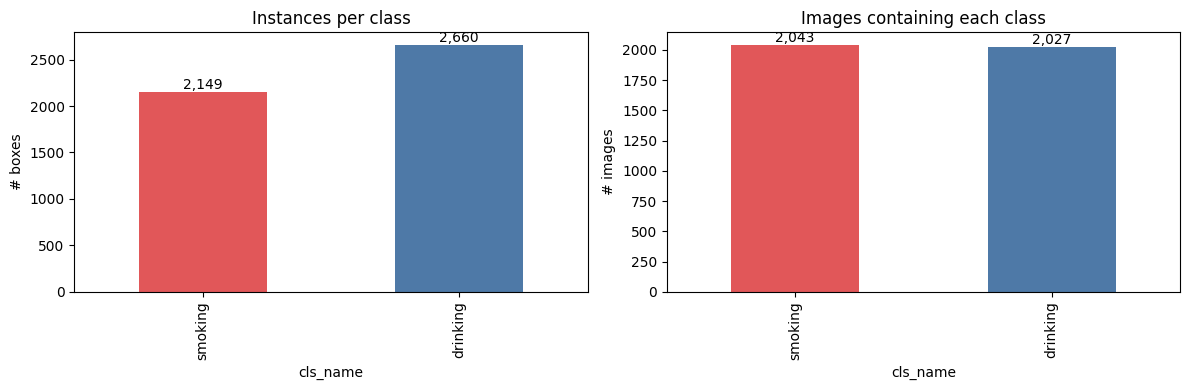

Instance imbalance ratio (max/min): 1.24x


In [ ]:
present = [c for c in UNIFIED_CLASSES if (inst["cls_name"] == c).any()]
palette = {"smoking": "#e15759", "drinking": "#4e79a7"}
colors  = [palette.get(c, "#59a14f") for c in present]

fig, ax = plt.subplots(1, 2, figsize=(12, 4))

inst["cls_name"].value_counts().reindex(present).plot(kind="bar", ax=ax[0], color=colors)
ax[0].set_title("Instances per class"); ax[0].set_ylabel("# boxes")
for i, v in enumerate(inst["cls_name"].value_counts().reindex(present)):
    ax[0].text(i, v, f"{int(v):,}", ha="center", va="bottom")

img_per_cls = inst.groupby("cls_name")["image"].nunique().reindex(present)
img_per_cls.plot(kind="bar", ax=ax[1], color=colors)
ax[1].set_title("Images containing each class"); ax[1].set_ylabel("# images")
for i, v in enumerate(img_per_cls):
    ax[1].text(i, v, f"{int(v):,}", ha="center", va="bottom")

plt.tight_layout(); plt.show()

imbalance = inst["cls_name"].value_counts()
if len(imbalance) >= 2:
    ratio = imbalance.max() / imbalance.min()
    print(f"Instance imbalance ratio (max/min): {ratio:.2f}x")
    if ratio > 1.5:
        print("→ Notable imbalance. Class-balanced augmentation (Section 10) will help even this out.")
else:
    print("Only one target class present — imbalance ratio not applicable.")

### 7.2 Boxes per image — how crowded are scenes?

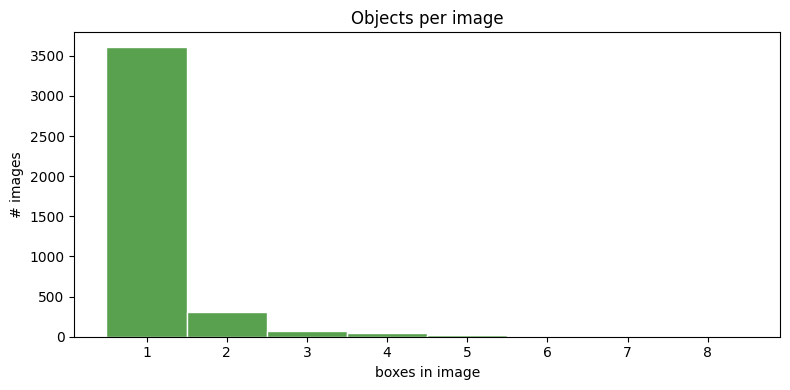

count    4069.00
mean        1.18
std         0.64
min         1.00
25%         1.00
50%         1.00
75%         1.00
max         8.00


In [ ]:
boxes_per_img = inst.groupby("image").size()
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(boxes_per_img, bins=range(1, boxes_per_img.max() + 2), align="left",
        color="#59a14f", edgecolor="white")
ax.set_title("Objects per image"); ax.set_xlabel("boxes in image"); ax.set_ylabel("# images")
plt.tight_layout(); plt.show()
print(boxes_per_img.describe().round(2).to_string())

### 7.3 Bounding-box geometry & small-object analysis

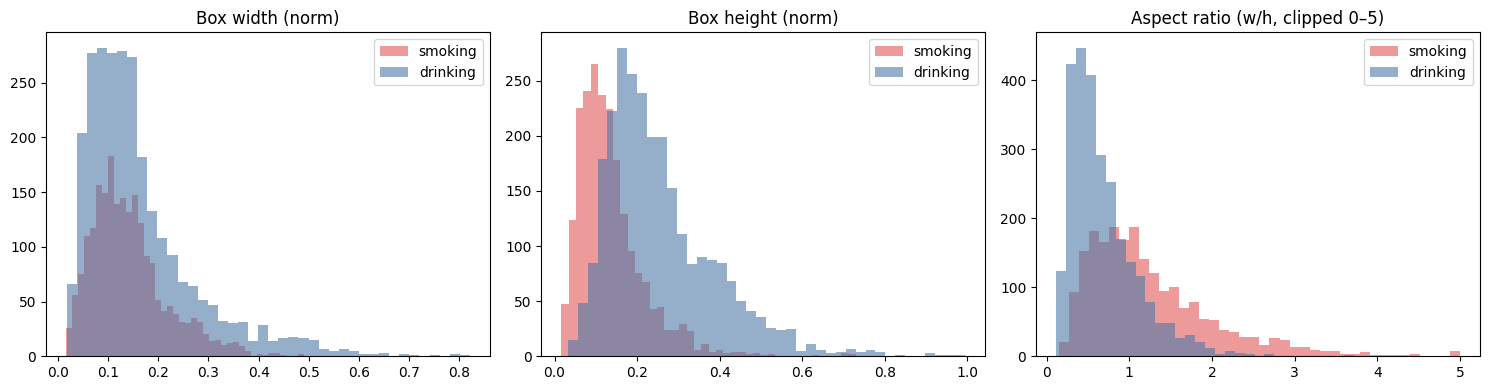

cls_name,drinking,smoking
size_bucket,,
tiny (<1%),339,738
small (1–5%),1508,1242
medium (5–15%),656,163
large (>15%),157,6


Share of tiny boxes (<1% of image): 22.4%
→ Many small objects: prefer a larger imgsz (e.g. 832/960) and avoid heavy downscaling.


In [ ]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
for cname in present:
    color = palette.get(cname, "#59a14f")
    sub = inst[inst["cls_name"] == cname]
    ax[0].hist(sub["w"], bins=40, alpha=0.6, label=cname, color=color)
    ax[1].hist(sub["h"], bins=40, alpha=0.6, label=cname, color=color)
    ax[2].hist(np.clip(sub["aspect"], 0, 5), bins=40, alpha=0.6, label=cname, color=color)
ax[0].set_title("Box width (norm)");  ax[1].set_title("Box height (norm)")
ax[2].set_title("Aspect ratio (w/h, clipped 0–5)")
for a in ax: a.legend()
plt.tight_layout(); plt.show()

def bucket(a):
    if a < 0.01: return "tiny (<1%)"
    if a < 0.05: return "small (1–5%)"
    if a < 0.15: return "medium (5–15%)"
    return "large (>15%)"
inst["size_bucket"] = inst["area"].map(bucket)
order = ["tiny (<1%)", "small (1–5%)", "medium (5–15%)", "large (>15%)"]
display(pd.crosstab(inst["size_bucket"], inst["cls_name"]).reindex(order))
tiny_share = (inst["area"] < 0.01).mean()
print(f"Share of tiny boxes (<1% of image): {tiny_share:.1%}")
if tiny_share > 0.15:
    print("→ Many small objects: prefer a larger imgsz (e.g. 832/960) and avoid heavy downscaling.")

### 7.4 Spatial prior — where do objects sit in the frame?

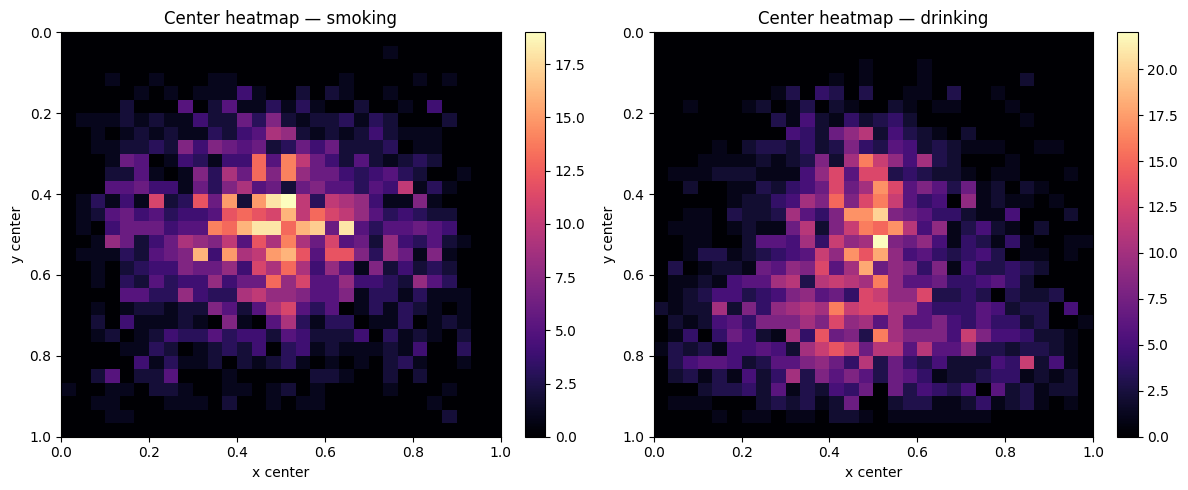

In [ ]:
cls_for_maps = present if present else UNIFIED_CLASSES
fig, ax = plt.subplots(1, len(cls_for_maps), figsize=(6 * len(cls_for_maps), 5))
if len(cls_for_maps) == 1: ax = [ax]
for a, cname in zip(ax, cls_for_maps):
    sub = inst[inst["cls_name"] == cname]
    h = a.hist2d(sub["xc"], sub["yc"], bins=30, range=[[0, 1], [0, 1]], cmap="magma")
    a.set_title(f"Center heatmap — {cname}")
    a.set_xlabel("x center"); a.set_ylabel("y center"); a.invert_yaxis()
    fig.colorbar(h[3], ax=a, fraction=0.046)
plt.tight_layout(); plt.show()

### 7.5 Per-dataset comparison — domain / annotation-style shift

If A and B disagree sharply on box sizes or resolution, the model may overfit to one source's
style. This is the check a naive "just concat them" workflow skips.

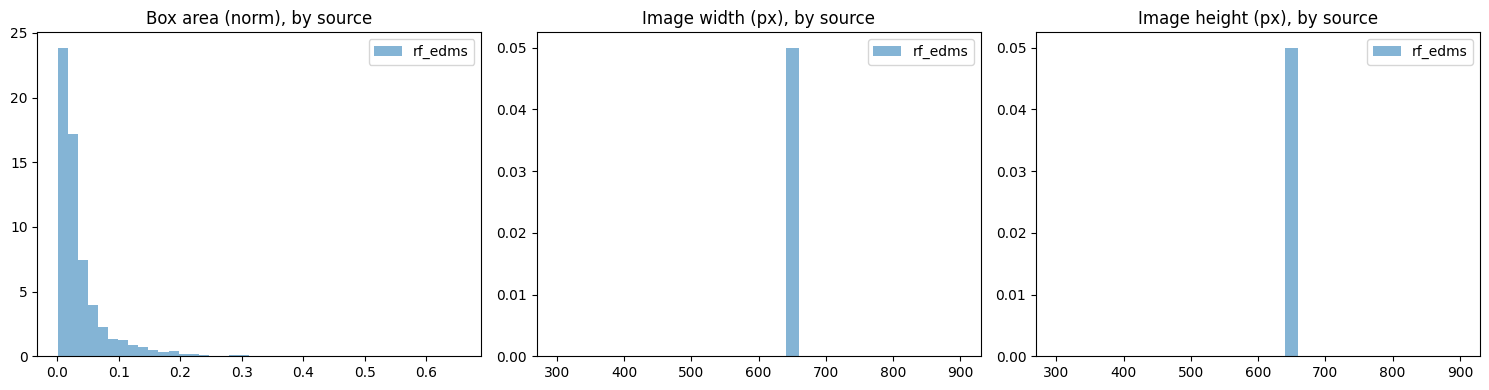

Class share by source:


cls_name,drinking,smoking
source,,
rf_edms,0.553,0.447


In [ ]:
# Per-source comparison generalized to however many sources you configured.
src_tags = sorted(inst["source"].unique())
color_cycle = plt.cm.tab10.colors

fig, ax = plt.subplots(1, 3, figsize=(15, 4))
for i, s in enumerate(src_tags):
    color = color_cycle[i % len(color_cycle)]
    sub = inst[inst["source"] == s]
    if sub.empty:
        continue
    ax[0].hist(sub["area"], bins=40, alpha=0.55, label=s, color=color, density=True)
    ax[1].hist(sub["img_w"].dropna(), bins=30, alpha=0.55, label=s, color=color,
               density=True, range=(300, 900))
    ax[2].hist(sub["img_h"].dropna(), bins=30, alpha=0.55, label=s, color=color,
               density=True, range=(300, 900))
ax[0].set_title("Box area (norm), by source")
ax[1].set_title("Image width (px), by source")
ax[2].set_title("Image height (px), by source")
for a in ax:
    a.legend()
plt.tight_layout(); plt.show()

print("Class share by source:")
display(pd.crosstab(inst["source"], inst["cls_name"], normalize="index").round(3))


### 7.6 Visual sanity check — sample images with boxes drawn

The most direct confirmation the fix worked: every drawn box should genuinely be smoking or
drinking, with **no hands-on-wheel boxes labelled as drinking**.

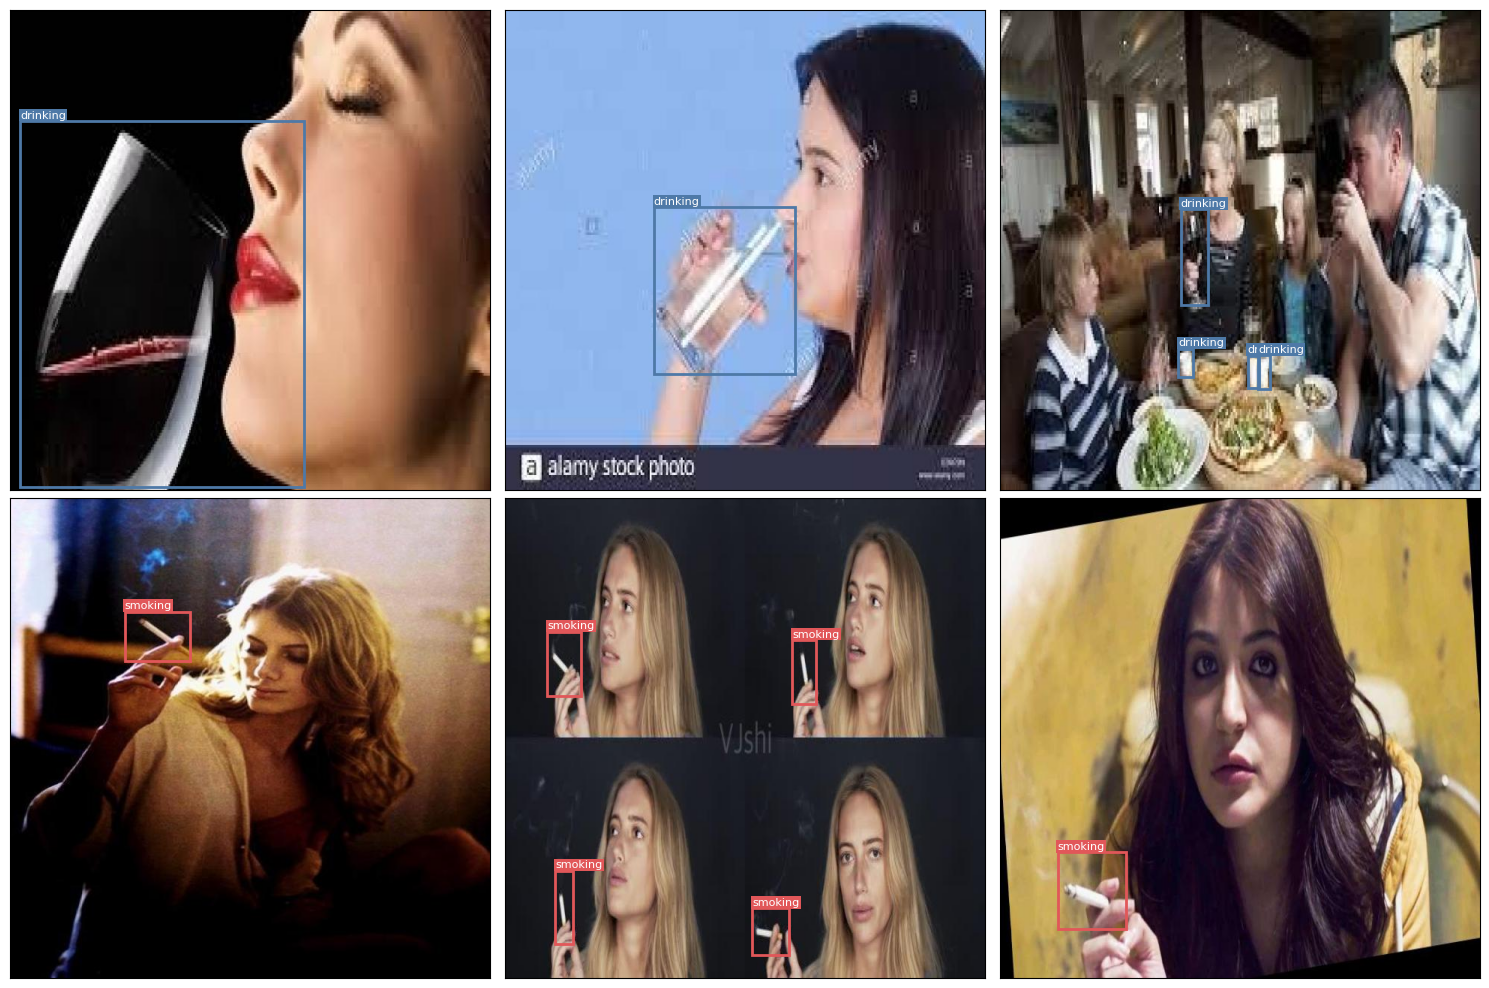

In [ ]:
def draw_sample(image_path, ax):
    im = cv2.cvtColor(cv2.imread(image_path), cv2.COLOR_BGR2RGB)
    H, W = im.shape[:2]
    ax.imshow(im)
    for _, r in inst[inst["image"] == image_path].iterrows():
        x = (r["xc"] - r["w"] / 2) * W; y = (r["yc"] - r["h"] / 2) * H
        rect = patches.Rectangle((x, y), r["w"] * W, r["h"] * H,
                                 linewidth=2, edgecolor=palette.get(r["cls_name"], "lime"),
                                 facecolor="none")
        ax.add_patch(rect)
        ax.text(x, max(y - 4, 0), r["cls_name"], color="white", fontsize=8,
                bbox=dict(facecolor=palette.get(r["cls_name"], "lime"), pad=1, edgecolor="none"))
    ax.set_xticks([]); ax.set_yticks([])

sample_imgs = (inst.groupby("cls_name")["image"].apply(
    lambda s: list(pd.Series(s.unique()).sample(min(3, s.nunique()), random_state=SEED)))
    ).explode().dropna().unique()[:6]

n = len(sample_imgs)
if n:
    fig, axes = plt.subplots((n + 2) // 3, 3, figsize=(15, 5 * ((n + 2) // 3)))
    for ax, p in zip(np.array(axes).ravel(), sample_imgs):
        draw_sample(p, ax)
    for ax in np.array(axes).ravel()[n:]:
        ax.axis("off")
    plt.tight_layout(); plt.show()
else:
    print("No target images to display.")

## 8 · Deduplication (before splitting)

Merged datasets frequently share frames. We perceptual-hash every image and keep one
representative per hash cluster, so duplicates cannot land on both sides of the split.

In [ ]:
import imagehash
all_pool = set(inst["image"].unique()) | negative_images
hash_map = defaultdict(list)
for p in all_pool:
    try:
        with Image.open(p) as im:
            hash_map[str(imagehash.phash(im))].append(p)
    except Exception:
        pass

dupes = {h: ps for h, ps in hash_map.items() if len(ps) > 1}
keep_images = {ps[0] for ps in hash_map.values()}
n_dropped = len(all_pool) - len(keep_images)
print(f"Duplicate clusters: {len(dupes)} | images dropped as duplicates: {n_dropped}")

inst = inst[inst["image"].isin(keep_images)].reset_index(drop=True)
negative_images = negative_images & keep_images
print(f"Target images after dedup: {inst['image'].nunique():,}"
      + (f" | negative images: {len(negative_images):,}" if KEEP_NEGATIVES else ""))

Duplicate clusters: 348 | images dropped as duplicates: 365
Target images after dedup: 3,704


## 8.5 · Balance the classes with **real images** (reviewer fix)

Instead of inflating the minority class with ~17× augmentation, we balance using real data. Each
image is assigned a **dominant class**, then the majority class is **downsampled** so it holds at
most `MAX_IMBALANCE_RATIO` × the minority-class image count. Every minority image is kept. This
runs *after* dedup and *before* the split, so balance is real and duplicate-free. Augmentation
(Section 10) then only has to close a tiny residual gap, hard-capped by `MAX_MINORITY_EXTRA`.


Images per dominant class BEFORE balancing:


,images
cls_name,
smoking,2010
drinking,1694



Minority class = 'drinking' (1694 images). Cap = 2118 images per class (1.25x minority).
Target images: 3,704 -> 3,704

Images per dominant class AFTER balancing:


,images
cls_name,
smoking,2010
drinking,1694


Image imbalance ratio: 1.19x  ->  1.19x


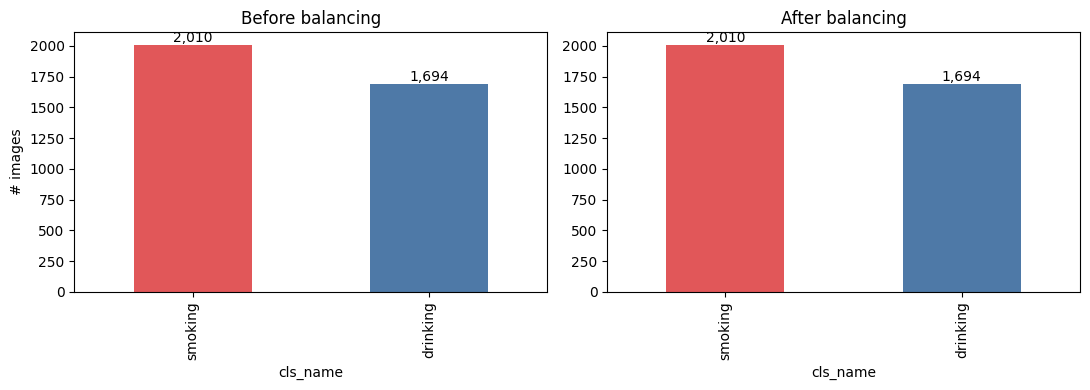

In [ ]:
# Real-image class balancing: cap the majority class's image count.
def _dominant_per_image(frame):
    return (frame.groupby("image")["cls_name"]
                 .agg(lambda s: s.value_counts().idxmax()))

img_dom_cls = _dominant_per_image(inst)
counts_before = img_dom_cls.value_counts().reindex(UNIFIED_CLASSES).fillna(0).astype(int)
print("Images per dominant class BEFORE balancing:")
display(counts_before.to_frame("images"))

if (counts_before > 0).sum() >= 2:
    minority_cls = counts_before.idxmin()
    minority_n   = int(counts_before.min())
    cap = int(round(minority_n * MAX_IMBALANCE_RATIO))

    rng_bal = np.random.default_rng(SEED)
    keep_imgs = set()
    for cls in UNIFIED_CLASSES:
        imgs_c = img_dom_cls[img_dom_cls == cls].index.tolist()
        if len(imgs_c) > cap:
            imgs_c = list(rng_bal.choice(imgs_c, size=cap, replace=False))
        keep_imgs.update(imgs_c)

    before_imgs = inst["image"].nunique()
    inst = inst[inst["image"].isin(keep_imgs)].reset_index(drop=True)
    if negative_images:
        negative_images = negative_images & keep_imgs

    print(f"\nMinority class = '{minority_cls}' ({minority_n} images). "
          f"Cap = {cap} images per class ({MAX_IMBALANCE_RATIO}x minority).")
    print(f"Target images: {before_imgs:,} -> {inst['image'].nunique():,}")

    counts_after = (_dominant_per_image(inst)
                    .value_counts().reindex(UNIFIED_CLASSES).fillna(0).astype(int))
    print("\nImages per dominant class AFTER balancing:")
    display(counts_after.to_frame("images"))

    r_before = counts_before.max() / max(counts_before.min(), 1)
    r_after  = counts_after.max()  / max(counts_after.min(), 1)
    print(f"Image imbalance ratio: {r_before:.2f}x  ->  {r_after:.2f}x")

    # quick before/after visual
    fig, ax = plt.subplots(1, 2, figsize=(11, 4))
    counts_before.plot(kind="bar", ax=ax[0], color=["#e15759", "#4e79a7"])
    ax[0].set_title("Before balancing"); ax[0].set_ylabel("# images")
    counts_after.plot(kind="bar", ax=ax[1], color=["#e15759", "#4e79a7"])
    ax[1].set_title("After balancing")
    for a, cc in zip(ax, [counts_before, counts_after]):
        for j, v in enumerate(cc):
            a.text(j, v, f"{int(v):,}", ha="center", va="bottom")
    plt.tight_layout(); plt.show()
else:
    print("Only one target class present — balancing skipped. "
          "Add a source that contains the missing class.")


## 9 · Train / val / test split (image-grouped, class-stratified)

Split at the **image** level (all boxes of an image stay together), stratified by each image's
**dominant class**. Negative images (if kept) are stratified as their own group. Deterministic
via `SEED`.

In [ ]:
# dominant class per target image
img_dom = (inst.groupby("image")["cls_name"]
                .agg(lambda s: s.value_counts().idxmax())
                .rename("dom_cls").reset_index())

# include negatives as their own stratum
if negative_images:
    img_dom = pd.concat([img_dom,
        pd.DataFrame({"image": list(negative_images), "dom_cls": "background"})],
        ignore_index=True)

rng = np.random.default_rng(SEED)
assign = {}
for cls, grp in img_dom.groupby("dom_cls"):
    imgs = grp["image"].tolist(); rng.shuffle(imgs)
    n = len(imgs)
    n_tr = int(round(n * SPLIT["train"]))
    n_va = int(round(n * SPLIT["val"]))
    for i, im in enumerate(imgs):
        assign[im] = "train" if i < n_tr else ("val" if i < n_tr + n_va else "test")

inst["split"] = inst["image"].map(assign)
print("Target images per split:")
display(inst.groupby("split")["image"].nunique().reindex(["train", "val", "test"]).to_frame("images"))
print("\nInstances per class per split:")
display(pd.crosstab(inst["split"], inst["cls_name"]).reindex(["train", "val", "test"]))

Target images per split:


,images
split,
train,2963
val,370
test,371



Instances per class per split:


cls_name,drinking,smoking
split,,
train,1813,1685
val,217,214
test,231,214


## 10 · Augmentation — **train split only**, bbox-aware & clamped

Albumentations transforms images and their boxes together; only label-preserving ops are used
(flips/scale/rotate + photometric jitter, no vertical flips, mild rotation). Because Section 8.5
already balanced the classes with real images, augmentation is **light**: a uniform
`AUG_PER_IMAGE`, plus at most `MAX_MINORITY_EXTRA` extra copies for any residual minority gap.
The old unbounded `round(max/min)-1` multiplier (which reached ~17×) is replaced by this clamp.


In [ ]:
transform = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.Affine(scale=(0.85, 1.15), translate_percent=(0.0, 0.06),
             rotate=(-12, 12), shear=(-4, 4), fit_output=False, p=0.7),
    A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.6),
    A.HueSaturationValue(hue_shift_limit=10, sat_shift_limit=20, val_shift_limit=15, p=0.4),
    A.OneOf([A.MotionBlur(blur_limit=5), A.GaussianBlur(blur_limit=5),
             A.GaussNoise(var_limit=(10, 40))], p=0.3),
    A.CLAHE(clip_limit=2.0, p=0.2),
], bbox_params=A.BboxParams(format="yolo", label_fields=["class_labels"],
                            min_visibility=0.3, min_area=1e-4))

cls_counts = inst[inst.split == "train"]["cls_name"].value_counts()
minority = cls_counts.idxmin() if (BALANCE_CLASSES and len(cls_counts) >= 2) else None

# Residual gap after real-image balancing -> tiny. HARD-CAP it so it can never
# explode to ~17x like the previous version did.
raw_extra = (int(round(cls_counts.max() / max(cls_counts.min(), 1))) - 1) if minority else 0
extra_for_minority = min(raw_extra, MAX_MINORITY_EXTRA)

print("Base aug/image:", AUG_PER_IMAGE, "| minority class:", minority)
print("Residual gap suggests extra:", raw_extra,
      "-> extra copies USED (clamped to <=%d):" % MAX_MINORITY_EXTRA, extra_for_minority)
if raw_extra > MAX_MINORITY_EXTRA:
    print(f"→ Clamped minority augmentation to {MAX_MINORITY_EXTRA} extra copies "
          f"(unclamped would be {raw_extra}). Real-image balancing already did the heavy lifting.")
max_total = AUG_PER_IMAGE + extra_for_minority + 1
print(f"→ Max total copies of any single image (orig + aug): {max_total}x "
      f"(was up to ~18x before).")


Base aug/image: 2 | minority class: smoking
Residual gap suggests extra: 0 -> extra copies USED (clamped to <=2): 0
→ Max total copies of any single image (orig + aug): 3x (was up to ~18x before).


## 11 · Export the YOLOv8 dataset → download to your laptop

Everything is written to **fast local disk** (not Drive), zipped once, and then pushed to your
browser as a download. Originals are copied byte-for-byte (no re-encode); augmented variants go
**only into `train/`** as JPEG. If the browser download is blocked (common for very large files),
the zip also stays in the Colab file browser so you can download it manually.

In [ ]:
import concurrent.futures, os, cv2, shutil
from pathlib import Path
from tqdm.notebook import tqdm

cv2.setNumThreads(0)  # avoid thread oversubscription across worker processes

# ── Write to local SSD (fast), NOT Drive ─────────────────────────────────────
DATASET_NAME = OUTPUT_ROOT
out = Path(WORK_DIR) / DATASET_NAME
if out.exists():
    shutil.rmtree(out)
for sub in ["images", "labels"]:
    for sp in ["train", "val", "test"]:
        (out / sub / sp).mkdir(parents=True, exist_ok=True)

JPEG_Q, AUG_AS_JPG = 90, True   # augmented copies as .jpg = faster + smaller than .png

def write_label(path, boxes):
    path.write_text("\n".join(f"{c} {x:.6f} {y:.6f} {w:.6f} {h:.6f}"
                              for c, x, y, w, h in boxes))

# group boxes per image without iterrows()
per_image = {img: list(zip(g.cls_id.astype(int), g.xc, g.yc, g.w, g.h))
             for img, g in inst.groupby("image")}
img_split = dict(zip(inst["image"], inst["split"]))
for p in negative_images:
    per_image.setdefault(p, []); img_split[p] = assign[p]

img_dom_map = dict(zip(img_dom["image"], img_dom["dom_cls"]))
src_tag = dict(zip(inst["image"], inst["source"]))
_src_roots = {s["tag"]: s["root"] for s in SOURCES}
def _tag_for_path(p):
    for tag, root in _src_roots.items():
        if str(root) in str(p):
            return tag
    return SOURCES[0]["tag"]
for p in negative_images:
    src_tag.setdefault(p, _tag_for_path(p))

def process_single_image(img_path):
    boxes = per_image[img_path]
    sp = img_split[img_path]
    stem = f"{src_tag.get(img_path, 'X')}_{Path(img_path).stem}"
    ext = Path(img_path).suffix.lower()
    shutil.copy(img_path, out / "images" / sp / f"{stem}{ext}")   # raw byte copy
    write_label(out / "labels" / sp / f"{stem}.txt", boxes)
    n_written, n_aug = 1, 0
    if sp == "train" and boxes:
        reps = AUG_PER_IMAGE
        if BALANCE_CLASSES and minority and img_dom_map.get(img_path) == minority:
            reps += extra_for_minority
        image = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)
        yolo_boxes = [[b[1], b[2], b[3], b[4]] for b in boxes]
        labels = [b[0] for b in boxes]
        aug_ext = ".jpg" if AUG_AS_JPG else ext
        for k in range(reps):
            try:
                t = transform(image=image, bboxes=yolo_boxes, class_labels=labels)
            except Exception:
                continue
            if not t["bboxes"]:
                continue
            aug_img = cv2.cvtColor(t["image"], cv2.COLOR_RGB2BGR)
            cv2.imwrite(str(out / "images" / sp / f"{stem}_aug{k}{aug_ext}"),
                        aug_img, [cv2.IMWRITE_JPEG_QUALITY, JPEG_Q])
            write_label(out / "labels" / sp / f"{stem}_aug{k}.txt",
                        [(lab, *bb) for bb, lab in zip(t["bboxes"], t["class_labels"])])
            n_aug += 1
    return n_written, n_aug

items = list(per_image.keys())
n_written = n_aug = 0
try:
    with concurrent.futures.ProcessPoolExecutor(max_workers=os.cpu_count()) as ex:
        for w, a in tqdm(ex.map(process_single_image, items, chunksize=16),
                         total=len(items), desc="Exporting (local)"):
            n_written += w; n_aug += a
except Exception as e:
    print(f"Process pool failed ({e}); falling back to threads.")
    with concurrent.futures.ThreadPoolExecutor() as ex:
        for w, a in tqdm(ex.map(process_single_image, items),
                         total=len(items), desc="Exporting (local, threads)"):
            n_written += w; n_aug += a

print(f"Originals written: {n_written} | augmented (train) written: {n_aug}")

# data.yaml uses a RELATIVE path so it works wherever you unzip it on your laptop
(out / "data.yaml").write_text(
    "path: .\ntrain: images/train\nval: images/val\ntest: images/test\n\n"
    f"nc: {len(UNIFIED_CLASSES)}\nnames: {UNIFIED_CLASSES}\n")
print("\ndata.yaml written (relative paths).")

# ── Zip once (fast) then trigger a browser download to your laptop ───────────
zip_base = str(Path(WORK_DIR) / DATASET_NAME)          # -> .../smoking_drinking_yolo.zip
zip_path = shutil.make_archive(zip_base, "zip", root_dir=out)
size_mb = os.path.getsize(zip_path) / 1e6
print(f"Archive ready: {zip_path}  ({size_mb:,.1f} MB)")

try:
    from google.colab import files
    files.download(zip_path)                            # <-- saves to your laptop's Downloads
    print("Download started in your browser.")
except Exception as e:
    print(f"Auto-download unavailable ({e}). Open the Colab Files panel (left sidebar), "
          f"find:\n    {zip_path}\nright-click \u2192 Download.")
print("\nAfter unzipping on your laptop, train with:  yolo detect train "
      "data=%s/data.yaml" % DATASET_NAME + " ...")

Exporting (local):   0%|          | 0/3704 [00:00<?, ?it/s]

Originals written: 3704 | augmented (train) written: 5921

data.yaml written (relative paths).
Archive ready: /content/work/smoking_drinking_yolo_balanced.zip  (726.2 MB)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Download started in your browser.

After unzipping on your laptop, train with:  yolo detect train data=smoking_drinking_yolo_balanced/data.yaml ...


---
### Handoff notes

* **Imbalance is fixed with real data, not 17× augmentation.** A balanced Roboflow source +
  the Section 8.5 cap bring the classes close in size; Section 10 augmentation is uniform and
  hard-capped (`MAX_MINORITY_EXTRA`). Check the Section 8.5 before/after chart and the Section 10
  print — no single image is duplicated anywhere near the old ~18× ceiling.
* **Everything comes from Roboflow via the API** — no Drive mount, no manual uploads.
* **`data.yaml`** uses relative paths, so it works wherever you unzip the dataset — point
  Ultralytics straight at it.
* **Harmonization is name-based.** If instance counts look off, re-read the Section 3.1 audit
  print — it shows exactly which source class mapped to which unified class (or `DROP`).
* **Size is set by the scarcer class.** After the Section 8.5 cap, both classes equal the
  smaller of (smoking, drinking) within the 8.3k source — check the Section 8.5 before/after
  counts to see the final per-class total. To grow further, uncomment the supplement source
  in the Config cell (or add another *drinking-action* source) — the pipeline picks them up by name and Section 8.5 re-balances
  automatically. Note: avoid "drunk/sober" face-state datasets; they detect intoxication, not the
  act of drinking, and would pollute the `drinking` class.
* **Val/test are augmentation-free and duplicate-free**, so metrics reflect real generalization.
* If the tiny-object share (Section 7.3) was high, bump `imgsz` (832–960) when training.
* Re-run only the Config cell to regenerate with different split / balance / augmentation settings.
